In [372]:
import pandas as pd

df = pd.read_csv("/Users/seongjeyeon/Downloads/aviation-analysis/ntsb_data.csv")
df.shape

(87951, 45)

In [373]:
import os
os.getcwd

<function posix.getcwd()>

In [374]:
df.shape
df.columns.tolist()

['Event Id',
 'Investigation Type',
 'Country',
 'Aircraft Damage',
 'Aircraft Category',
 'Make',
 'Model',
 'Amateur Built',
 'Number Of Engines',
 'Engine Type',
 'Far Description',
 'Schedule',
 'Purpose Of Flight',
 'Total Fatal Injuries',
 'Total Serious Injuries',
 'Total Minor Injuries',
 'Total Uninjured',
 'Weather Condition',
 'Broad Phase Of Flight',
 'Analysis',
 'City',
 'Longitude',
 'Latitude',
 'Address',
 'geometry',
 'Place',
 'Number Of Seats',
 'Type Aircraft',
 'Type Engine',
 'Total Person',
 'Far Description Factorized',
 'Schedule Factorized',
 'Purpose Of Flight Factorized',
 'Make Factorized',
 'Model Factorized',
 'Event Year',
 'Publication Year',
 'Event Month',
 'Publication Month',
 'Event Day',
 'Publication Day',
 'Date Difference',
 'Publication Month Name',
 'Event Month Name',
 'Season']

In [375]:
cols = ['Event Year', 'Make', 'Model', 'Broad Phase Of Flight',
        'Total Fatal Injuries', 'Analysis']

df_clean = df[cols].copy()
df_clean = df_clean.dropna(subset=['Analysis'])

print(df_clean.shape)
df_clean.head()

(87951, 6)


,Event Year,Make,Model,Broad Phase Of Flight,Total Fatal Injuries,Analysis
0,1948,stinson,108-3,Cruise,2,"\n \n ON OCTOBER 24, 1948, T..."
1,1962,piper,pa24-180,Unknown,4,"\n \n ON JULY 19, 1962, A CO..."
2,1974,cessna,172m,Cruise,3,\n \n The private pilot was ...
3,1977,rockwell,112,Cruise,2,\n \n The aircraft wreckage ...
4,1979,cessna,501,Approach,1,\n \n The Safety Board's ful...


In [376]:
df_clean.to_csv('aviation_cleaned.csv', index=False)

In [377]:
# Filter to only fatal accidents (at least 1 death)
fatal = df_clean[df_clean['Total Fatal Injuries'] > 0]

# top 15 manufacturers by fatal accident count
fatal['Make'].value_counts().head(15)

Make
cessna               5196
piper                3513
beech                1729
bell                  689
robinson              427
mooney                409
boeing                398
bellanca              226
de havilland          169
hughes                157
aerospatiale          140
grumman               137
mcdonnell douglas     135
north american        132
aero commander        129
Name: count, dtype: int64

In [378]:
# Group fatal accidents by year, sort chronologically
fatal_by_year = fatal.groupby('Event Year').size().sort_index()

fatal_by_year

Event Year
1948      1
1962      1
1974      1
1977      1
1979      1
1981      1
1982    678
1983    698
1984    653
1985    593
1986    531
1987    511
1988    539
1989    507
1990    530
1991    513
1992    519
1993    462
1994    492
1995    487
1996    456
1997    431
1998    448
1999    430
2000    477
2001    718
2002    709
2003    719
2004    677
2005    668
2006    636
2007    595
2008    402
2009    375
2010    366
2011    413
2012    410
2013    371
2014    372
2015    389
2016    368
2017    367
2018    401
2019    407
2020    312
2021    303
2022    325
dtype: int64

## Key findings from initial exploration

**1. Fleet-size bias explains the top-makes ranking.**
Cessna (26,836), Piper (14,743), and Beech (5,332) lead the raw accident 
counts, but this reflects fleet size and pilot demographics — these are 
the most common general aviation aircraft — not manufacturer quality. 
Without flight-hour denominators, raw counts can't answer "which aircraft 
is safest."

**2. Fatal accidents dropped ~40% starting 2008.**
From ~650–720 fatal accidents per year in 2001–2007 to ~370–410 per year 
post-2008. Plausible drivers include the post-financial-crisis decline in 
general aviation flight hours, glass cockpit and ADS-B adoption, and 
changes in the GA pilot population. Causal attribution requires flight-hour 
data this dataset does not contain.

**3. Maneuvering is the most lethal phase of flight, not the most common.**
Maneuvering accidents are 2.39× over-represented in fatal accidents vs 
non-fatal (17.4% of fatal accidents happen during maneuvering, but only 
7.3% of non-fatal). By contrast, Landing accidents are 3.85× under-represented 
in fatal accidents (9.6% fatal vs 37.0% non-fatal). 

This reveals a frequency-vs-lethality split: landings produce many accidents 
but few deaths (low speed, close to ground — recoverable); maneuvering 
produces fewer accidents but disproportionately kills people (low altitude, 
aggressive control inputs, often discretionary flight). Safety interventions 
targeting pilot decision-making in low-altitude discretionary flight would 
likely have higher impact than interventions focused on the phase with the 
most raw incidents.

**4. Amateur-built aircraft have a 32% higher fatality rate per accident 
than factory-built.**
Amateur-built: 29.5% of accidents are fatal. Factory-built: 22.4%. 
The gap likely reflects multiple regulatory differences, not manufacturing 
quality: each homebuilt is a unique machine without a standardized type 
certificate, meaning no standardized training or emergency procedures; the 
builder is often the primary maintainer (reducing independent inspection); 
and fatal accidents are known to cluster in the early Phase I test-flight 
period when pilots are learning an aircraft's specific handling 
characteristics.

---

**Methodology caveat:** All findings above describe accident counts and 
per-accident fatality rates. None describe accidents *per flight hour*, 
which is the correct denominator for comparing risk across aircraft types, 
phases, or pilot populations. Flight-hour data is available separately 
through the FAA General Aviation and Part 135 Activity Survey — integrating 
that data would be a logical Phase 2 extension of this project.

In [379]:
# Drop pre-1982 (sparse / unreliable digitization)
df_clean = df_clean[df_clean['Event Year'] >= 1982]

# Standardize manufacturer names — they're inconsistent
df_clean['Make'] = df_clean['Make'].str.upper().str.strip()

# Confirm the cleanup
print(df_clean.shape)
df_clean['Make'].value_counts().head(10)

(87944, 6)


Make
CESSNA      26836
PIPER       14743
BEECH        5332
BELL         2706
BOEING       2652
MOONEY       1322
ROBINSON     1223
GRUMMAN      1158
BELLANCA     1033
HUGHES        931
Name: count, dtype: int64

In [380]:
fatal = df_clean[df_clean['Total Fatal Injuries'] > 0] 
print(fatal.shape)

(20258, 6)


In [381]:
fatal_phase = fatal['Broad Phase Of Flight'].value_counts(normalize=True).head(8)
nonfatal = df_clean[df_clean['Total Fatal Injuries'] == 0]
nonfatal_phase = nonfatal['Broad Phase Of Flight'].value_counts(normalize=True).head(8)
comparison = pd.DataFrame({'fatal_pct': fatal_phase, 'nonfatal_pct': nonfatal_phase})
comparison['ratio'] = comparison['fatal_pct'] / comparison['nonfatal_pct']
print(comparison.sort_values('ratio', ascending=False))

                       fatal_pct  nonfatal_pct     ratio
Broad Phase Of Flight                                   
Maneuvering             0.174005      0.072689  2.393847
Climb                   0.048327      0.023757  2.034225
Unknown                 0.186642      0.099149  1.882443
Cruise                  0.158801      0.107157  1.481957
Approach                0.113634      0.080918  1.404316
Takeoff                 0.150706      0.169828  0.887401
Landing                 0.096110      0.370180  0.259631
Descent                 0.034110           NaN       NaN
Taxi                         NaN      0.028204       NaN


In [382]:
cols2 = ['Event Year', 'Make', 'Broad Phase Of Flight', 
         'Total Fatal Injuries', 'Weather Condition',
         'Aircraft Category','Amateur Built', 'Season']
df2 = df[df['Event Year'] >= 1982][cols2].copy()
print(df2.shape)
df2.head()

(87944, 8)


,Event Year,Make,Broad Phase Of Flight,Total Fatal Injuries,Weather Condition,Aircraft Category,Amateur Built,Season
7,1982,cessna,Takeoff,0,VMC,airplane,No,Winter
8,1982,cessna,Landing,0,IMC,airplane,No,Winter
9,1982,north american,Cruise,0,IMC,fixed wing single engine,No,Winter
10,1982,piper,Approach,0,VMC,fixed wing single engine,No,Winter
11,1982,beech,Landing,0,VMC,fixed wing single engine,No,Winter


In [383]:
df2.assign(is_fatal=(df2['Total Fatal Injuries'] > 0))\
    .groupby('Amateur Built')['is_fatal'].mean()


Amateur Built
No     0.223555
Yes    0.294537
Name: is_fatal, dtype: float64

## Today I learned

That Cessna leading the fatal-accident list isn't a quality signal — it's a 
fleet-size and pilot-demographics signal. Without flight-hour denominators, 
raw counts can mislead. Always ask "per what?" before drawing a conclusion.

# Visualizations

The findings above are summarized in tree charts below.

In [384]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.figsize': (10,6,),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

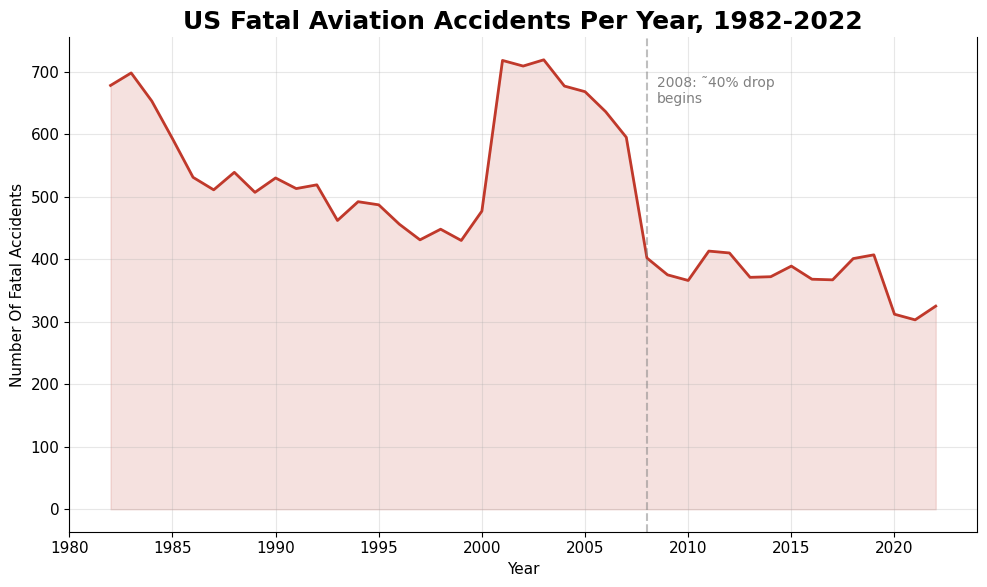

In [385]:
fatal = df_clean[df_clean['Total Fatal Injuries'] > 0]
fatal_by_year = fatal.groupby('Event Year').size()

fig, ax = plt.subplots()
ax.plot(fatal_by_year.index, fatal_by_year.values,
        linewidth=2, color='#c0392b')
ax.fill_between(fatal_by_year.index, fatal_by_year.values,
                alpha=0.15, color='#c0392b')

ax.axvline(x=2008, color='gray', linestyle='--', alpha=0.5)
ax.text(2008.5, 650, '2008: ˜40% drop\nbegins', fontsize=10, color='gray')

ax.set_title('US Fatal Aviation Accidents Per Year, 1982-2022')
ax.set_xlabel('Year')
ax.set_ylabel('Number Of Fatal Accidents')

plt.tight_layout()
plt.savefig('chart1_fatal_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

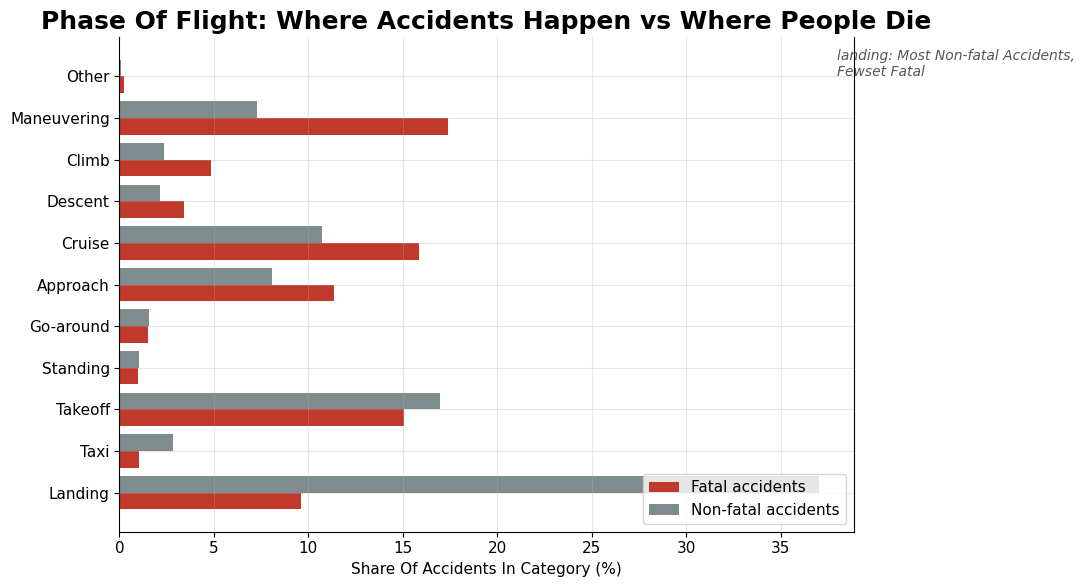

In [386]:
fatal = df_clean[df_clean['Total Fatal Injuries'] > 0]
nonfatal = df_clean[df_clean['Total Fatal Injuries'] == 0]

fatal_phase = fatal['Broad Phase Of Flight'].value_counts(normalize=True) * 100
nonfatal_phase = nonfatal['Broad Phase Of Flight'].value_counts(normalize=True) * 100

comparison = pd.DataFrame({
    'Fatal accidents (%)': fatal_phase,
    'Non-fatal accidents (%)': nonfatal_phase
}).drop('Unknown', errors='ignore').dropna()

comparison['ratio'] = comparison['Fatal accidents (%)'] / comparison['Non-fatal accidents (%)']
comparison = comparison.sort_values('ratio', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

import numpy as np
phases = comparison.index
y_pos =  np.arange(len(phases))
bar_height = 0.4

ax.barh(y_pos - bar_height/2, comparison['Fatal accidents (%)'],
        bar_height, label='Fatal accidents', color='#c0392b')
ax.barh(y_pos + bar_height/2, comparison['Non-fatal accidents (%)'],
        bar_height, label='Non-fatal accidents', color='#7f8c8d')

ax.set_yticks(y_pos)
ax.set_yticklabels(phases)
ax.set_xlabel('Share Of Accidents In Category (%)')
ax.set_title('Phase Of Flight: Where Accidents Happen vs Where People Die')
ax.legend(loc='lower right')

ax.text(38, len(phases)-1,
        'landing: Most Non-fatal Accidents, \nFewset Fatal',
        fontsize=10, color='#555', style='italic')

plt.tight_layout()
plt.savefig('chart2_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


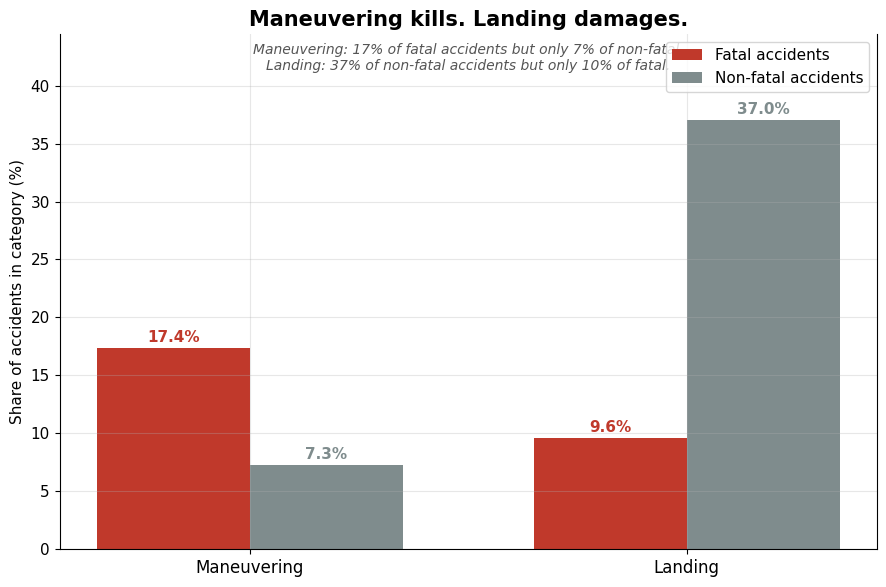

In [387]:
# Build the data — only the 2 phases that matter for the story
fatal = df_clean[df_clean['Total Fatal Injuries'] > 0]
nonfatal = df_clean[df_clean['Total Fatal Injuries'] == 0]

fatal_phase = fatal['Broad Phase Of Flight'].value_counts(normalize=True) * 100
nonfatal_phase = nonfatal['Broad Phase Of Flight'].value_counts(normalize=True) * 100

# Pull only the two phases we care about
phases_to_show = ['Maneuvering', 'Landing']
fatal_vals = [fatal_phase[p] for p in phases_to_show]
nonfatal_vals = [nonfatal_phase[p] for p in phases_to_show]

# The chart — vertical bars this time, since we only have 2 phases
import numpy as np
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(phases_to_show))
bar_width = 0.35

bars1 = ax.bar(x - bar_width/2, fatal_vals, bar_width, 
               label='Fatal accidents', color='#c0392b')
bars2 = ax.bar(x + bar_width/2, nonfatal_vals, bar_width,
               label='Non-fatal accidents', color='#7f8c8d')

# Value labels on top of each bar — no squinting required
for bar, val in zip(bars1, fatal_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#c0392b')
for bar, val in zip(bars2, nonfatal_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#7f8c8d')

ax.set_xticks(x)
ax.set_xticklabels(phases_to_show, fontsize=12)
ax.set_ylabel('Share of accidents in category (%)')
ax.set_title('Maneuvering kills. Landing damages.', fontsize=15)
ax.legend(loc='upper right')
ax.set_ylim(0, max(max(fatal_vals), max(nonfatal_vals)) * 1.2)

# Subtitle below the title
ax.text(0.5, 0.93, 
        'Maneuvering: 17% of fatal accidents but only 7% of non-fatal.\n'
        'Landing: 37% of non-fatal accidents but only 10% of fatal.',
        transform=ax.transAxes, ha='center', fontsize=10, 
        style='italic', color='#555')

plt.tight_layout()
plt.savefig('chart2_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

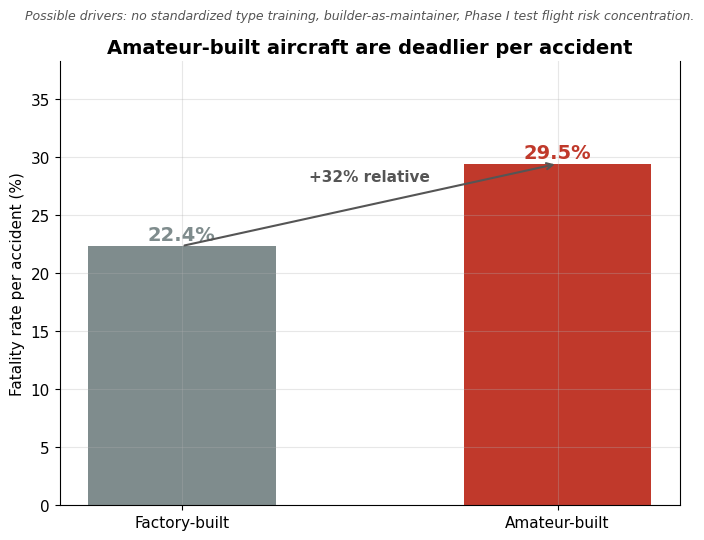

In [388]:
amateur_data = df[(df['Event Year'] >= 1982)][['Amateur Built', 'Total Fatal Injuries']].copy()
amateur_data = amateur_data[amateur_data['Amateur Built'].isin(['Yes', 'No'])]

amateur_data['is_fatal'] = amateur_data['Total Fatal Injuries'] > 0
fatality_rate = amateur_data.groupby('Amateur Built')['is_fatal'].mean() * 100

fatality_rate = fatality_rate.reindex(['No', 'Yes'])
labels = ['Factory-built', 'Amateur-built']
values = fatality_rate.values

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, values, color=['#7f8c8d', '#c0392b'], width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold',
            color=bar.get_facecolor())

diff_pct = ((values[1] - values[0]) / values[0]) * 100
ax.annotate('', xy=(1, values[1]), xytext=(0, values[0]),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.text(0.5, (values[0] + values[1])/2 + 2,
        f'+{diff_pct:.0f}% relative',
        ha='center', fontsize=11, color='#555', fontweight='bold')

ax.set_ylabel('Fatality rate per accident (%)')
ax.set_title('Amateur-built aircraft are deadlier per accident', fontsize=14)
ax.set_ylim(0, max(values) * 1.3)

fig.text(0.5, 0.92,
        'Possible drivers: no standardized type training, builder-as-maintainer, '
        'Phase I test flight risk concentration.',
        ha='center', fontsize=9, style='italic', color='#555')

plt.subplots_adjust(top=0.85)
plt.savefig('chart3_amateur_built.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualizations

The findings above are summarized in tree charts below.